In [21]:
import torch  # Import necessary libraries for training and data processing
import torchvision  # Import necessary libraries for training and data processing
import torchvision.transforms as transforms  # Import necessary libraries for training and data processing
from torchvision.datasets import StanfordCars  # Import necessary libraries for training and data processing
from torchvision.models import resnet50, efficientnet_b0  # Import necessary libraries for training and data processing
from torch.utils.data import DataLoader, random_split  # Import necessary libraries for training and data processing
import torch.nn as nn  # Import necessary libraries for training and data processing
import numpy as np  # Import necessary libraries for training and data processing
from sklearn.neighbors import NearestNeighbors  # Import necessary libraries for training and data processing
from tqdm import tqdm  # Import necessary libraries for training and data processing
import matplotlib.pyplot as plt  # Import necessary libraries for training and data processing

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set device to GPU if available, otherwise use CPU
print(f"Using device: {device}")

Using device: cuda


In [15]:
transform = transforms.Compose([  # Define data augmentation and preprocessing steps
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)  # Add cutout
])

train_dataset = StanfordCars(root='./', split='train', download=False, transform=transform)  # Load the Stanford Cars dataset with transformations
test_dataset = StanfordCars(root='./', split='test', download=False, transform=transform)  # Load the Stanford Cars dataset with transformations

In [16]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])  # Split training data into training and validation sets

print(f"Train size: {train_size}, Validation size: {val_size}")

Train size: 6515, Validation size: 1629


In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [33]:
NUM_CLASSES = 196

# Load pretrained EfficientNet
model = efficientnet_b0(weights="IMAGENET1K_V1")  # Load the EfficientNet-B0 model with pretrained weights


# Replace classifier head for Cars196
model.classifier[0] = torch.nn.Dropout(p=0.3)  # Increase dropout rate  # Add dropout to prevent overfitting
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)  # Adjust the classifier head to match the number of classes
model = model.to(device)

# Loss and Optimizer
criterion = torch.nn.CrossEntropyLoss()  # Define loss function for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=8e-5, weight_decay=2e-4)  # Define Adam optimizer with learning rate and weight decay
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(  # Adjust learning rate when validation loss stops improving
    optimizer, mode='min', patience=3, factor=0.5)


In [34]:
from sklearn.metrics import precision_score  # Import necessary libraries for training and data processing

EPOCHS = 15
best_val_loss = float('inf')
patience = 3  # Stop training if validation loss doesn't improve after 5 epochs
patience_counter = 0

for epoch in range(EPOCHS):  # Start training loop for the defined number of epochs
    # ========== TRAINING ==========
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_preds = []
    train_labels = []
    
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Reset gradients before backpropagation
        outputs = model(images)  # Forward pass to get model predictions
        loss = criterion(outputs, labels)

        loss.backward()  # Backpropagate loss to compute gradients
        optimizer.step()  # Update model weights based on gradients

        train_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(outputs, 1)  # Get the predicted class with the highest score
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Collect predictions and labels for precision calculation
        train_preds.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    # Compute train loss, accuracy, and precision
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_precision = precision_score(train_labels, train_preds, average='weighted', zero_division=0)  # Calculate precision for evaluation

    # ========== VALIDATION ==========
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  # Forward pass to get model predictions
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Accuracy calculation
            _, predicted = torch.max(outputs, 1)  # Get the predicted class with the highest score
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            # Collect predictions and labels for precision calculation
            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    # Compute validation loss, accuracy, and precision
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_precision = precision_score(val_labels, val_preds, average='weighted', zero_division=0)  # Calculate precision for evaluation

    # ========== OUTPUT ==========
    print(f"\nEpoch [{epoch + 1}/{EPOCHS}]")
    print(f"🟢 Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Precision: {train_precision:.4f}")
    print(f"🔵 Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Precision:   {val_precision:.4f}")

    # ========== LEARNING RATE SCHEDULING ==========
    scheduler.step(val_loss)  # Adjust learning rate if needed

    # ========== EARLY STOPPING ==========
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'efficientnet_cars196_best.pth')  # Save the best model based on validation loss
        print("✅ Model saved (best validation loss)")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement in validation loss for {patience_counter}/{patience} epochs.")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping triggered after {patience} epochs without improvement.")
        break

print("\n🎉 Training Complete!")


100%|██████████| 204/204 [00:59<00:00,  3.44it/s]



Epoch [1/15]
🟢 Train Loss: 5.2331 | Train Acc: 0.0126 | Train Precision: 0.0141
🔵 Val Loss:   5.1001 | Val Acc:   0.0442 | Val Precision:   0.0509
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:58<00:00,  3.49it/s]



Epoch [2/15]
🟢 Train Loss: 4.8368 | Train Acc: 0.0876 | Train Precision: 0.0940
🔵 Val Loss:   4.5062 | Val Acc:   0.1179 | Val Precision:   0.1485
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:55<00:00,  3.65it/s]


...


Epoch [13/15]
🟢 Train Loss: 0.7626 | Train Acc: 0.8434 | Train Precision: 0.8457
🔵 Val Loss:   1.0844 | Val Acc:   0.7047 | Val Precision:   0.7373
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:57<00:00,  3.53it/s]



Epoch [14/15]
🟢 Train Loss: 0.6642 | Train Acc: 0.8637 | Train Precision: 0.8658
🔵 Val Loss:   1.0037 | Val Acc:   0.7354 | Val Precision:   0.7720
✅ Model saved (best validation loss)


100%|██████████| 204/204 [00:57<00:00,  3.54it/s]



Epoch [15/15]
🟢 Train Loss: 0.5932 | Train Acc: 0.8758 | Train Precision: 0.8777
🔵 Val Loss:   0.9827 | Val Acc:   0.7317 | Val Precision:   0.7718
✅ Model saved (best validation loss)

🎉 Training Complete!


In [1]:
# Load the best model
model.load_state_dict(torch.load('efficientnet_cars196_best.pth'))
model.eval()

# Remove the classifier head to extract embeddings
embedding_model = torch.nn.Sequential(*(list(model.children())[:-1]))
embedding_model = embedding_model.to(device)

NameError: name 'model' is not defined

In [2]:
embeddings = []
file_names = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        embedding = embedding_model(images).squeeze(-1).squeeze(-1)
        embeddings.extend(embedding.cpu().numpy())
        file_names.extend(labels.cpu().numpy())

embeddings = np.array(embeddings)

NameError: name 'torch' is not defined

In [39]:
def retrieve_images(query_idx):
    # Step 1: Get the query embedding
    query_embedding = embeddings[query_idx]

    # Step 2: Compute Euclidean distances manually
    distances = np.linalg.norm(embeddings - query_embedding, axis=1)

    # Step 3: Sort by distance and exclude the query itself
    sorted_indices = np.argsort(distances)
    retrieved_indices = [idx for idx in sorted_indices if idx != query_idx][:5]
    retrieved_distances = [distances[idx] for idx in retrieved_indices]

    # Step 4: Create a plot to display results
    fig, axs = plt.subplots(1, len(retrieved_indices) + 1, figsize=(20, 5))
    
    # Query image
    query_img, _ = test_dataset[query_idx]
    axs[0].imshow(query_img.permute(1, 2, 0))
    axs[0].set_title("Query")
    axs[0].axis("off")

    # Retrieved images with distances
    for i, (idx, dist) in enumerate(zip(retrieved_indices, retrieved_distances)):
        retrieved_img, _ = test_dataset[idx]
        axs[i + 1].imshow(retrieved_img.permute(1, 2, 0))
        axs[i + 1].set_title(f"Dist: {dist:.3f}")
        axs[i + 1].axis("off")

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.907974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9254032].


🔎 Retrieval 1:


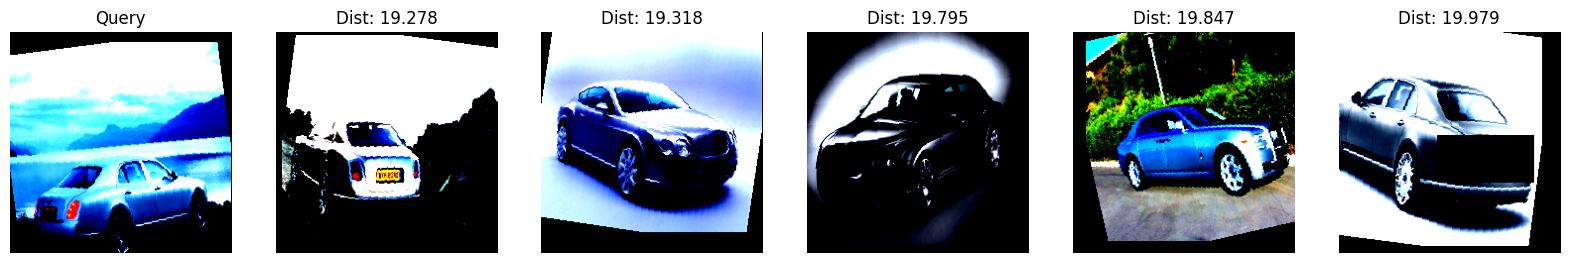

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1345534].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.0016559].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.7162529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9254032].


🔎 Retrieval 2:


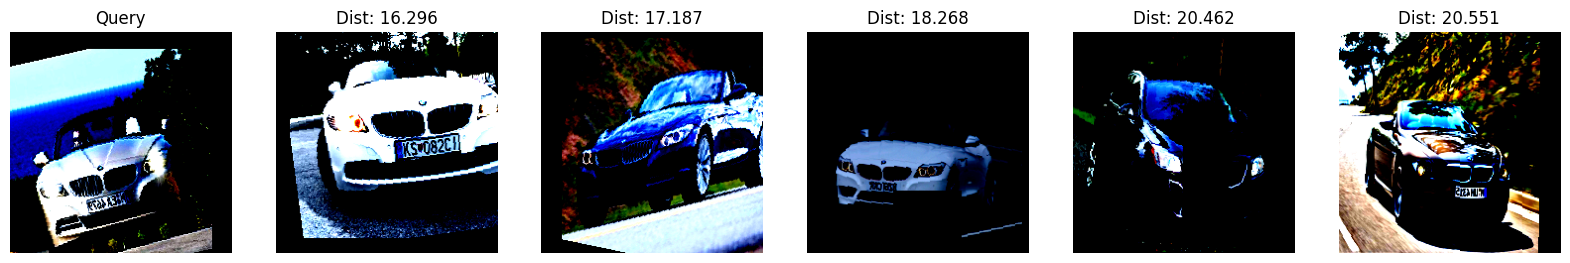

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5942485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2042704].


🔎 Retrieval 3:


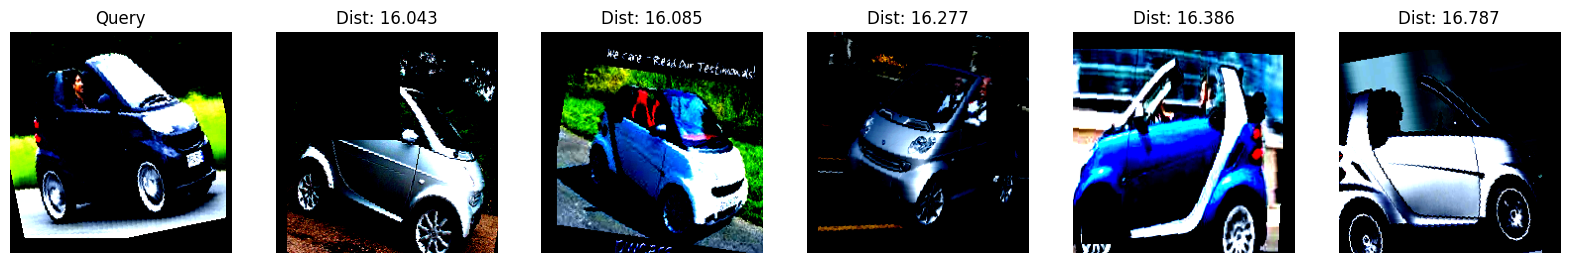

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.1236603].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8731157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0125492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 4:


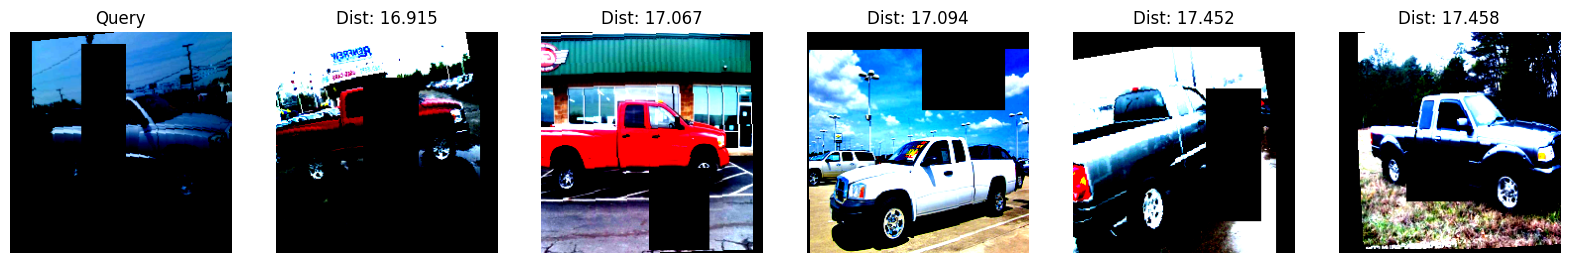

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3328106].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5245317].


🔎 Retrieval 5:


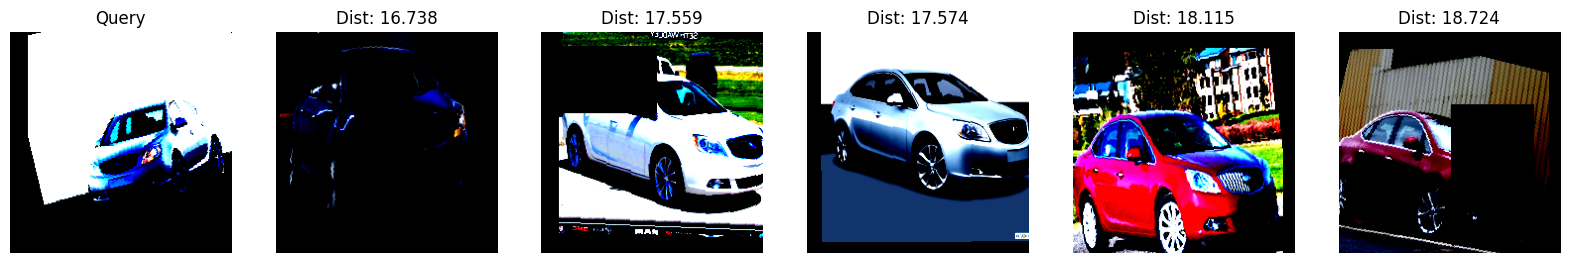

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3328106].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2042704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 6:


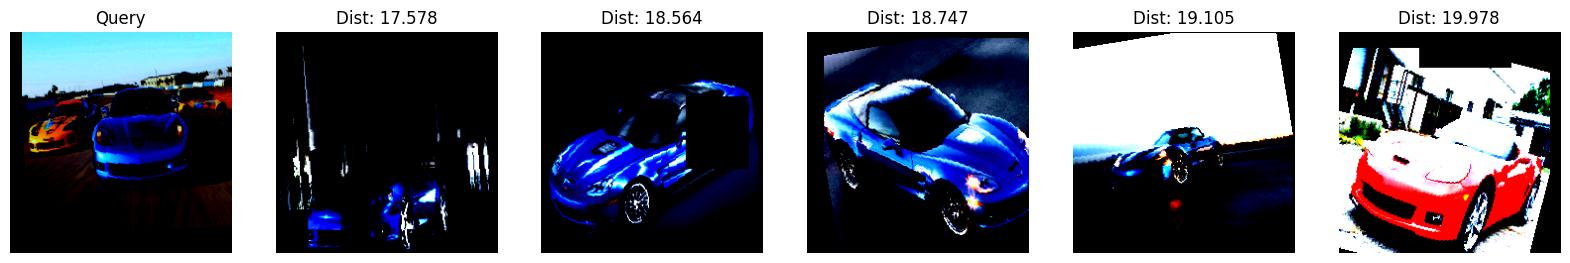

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4373858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3785625].


🔎 Retrieval 7:


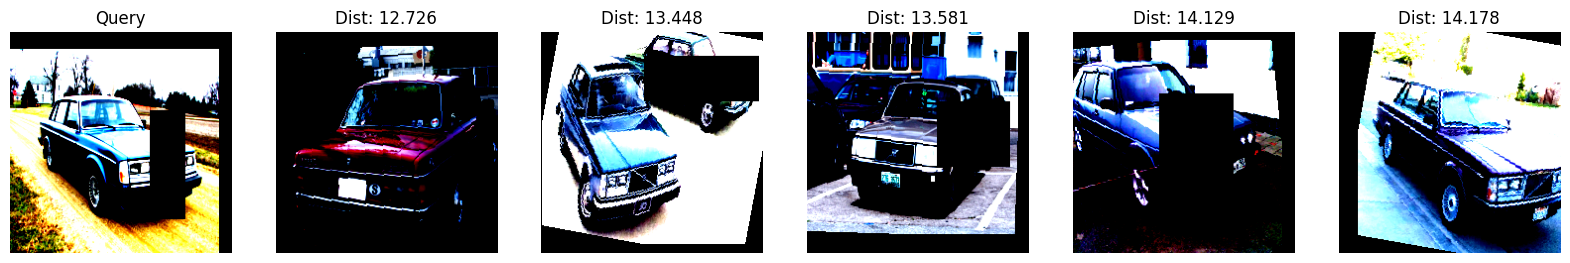

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.6988237].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5071026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 8:


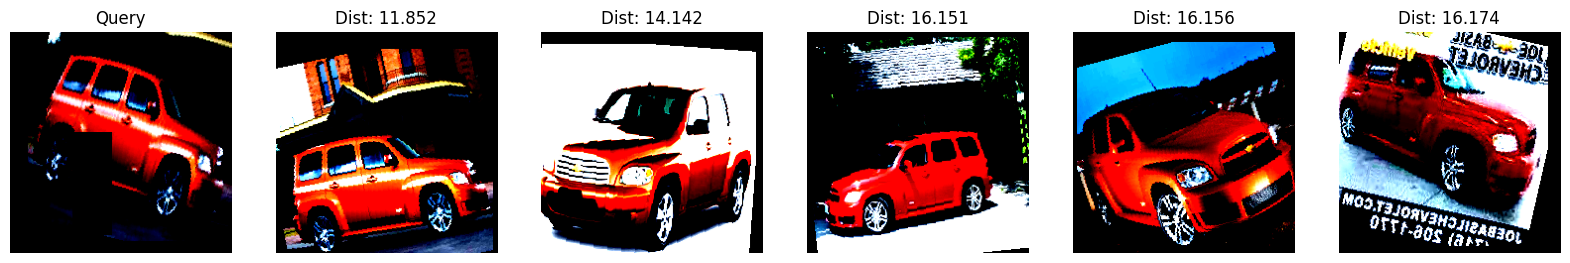

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3502399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


🔎 Retrieval 9:


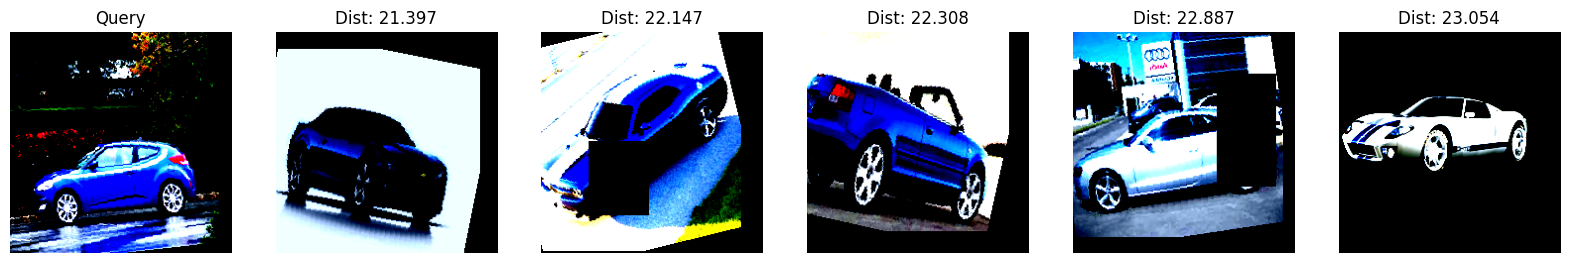

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.0713727].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3153814].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3502399].


🔎 Retrieval 10:


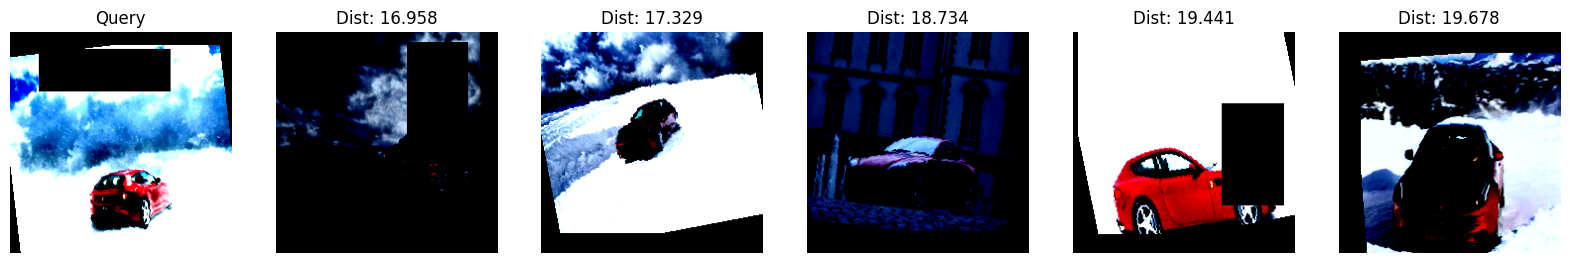

In [40]:
import random  # Import necessary libraries for training and data processing

def retrieve_random_cars(num_samples=10):
    random_indices = random.sample(range(len(test_dataset)), num_samples)
    
    for i, idx in enumerate(random_indices):
        print(f"🔎 Retrieval {i + 1}:")
        retrieve_images(idx)  # Call the existing retrieval function

# Run the loop
retrieve_random_cars(10)


✅ Mosaic saved to clustering_mosaic.png


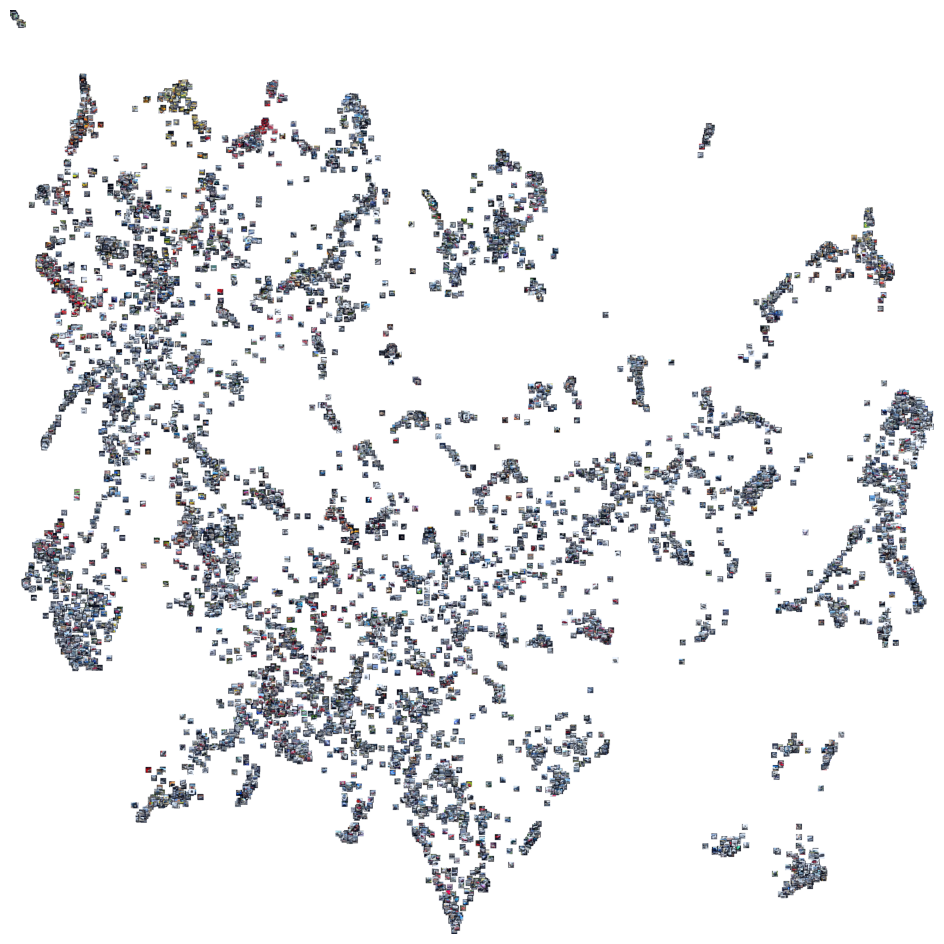

In [41]:
from sklearn.manifold import TSNE  # Import necessary libraries for training and data processing
from PIL import Image, ImageDraw  # Import necessary libraries for training and data processing
import numpy as np  # Import necessary libraries for training and data processing
import matplotlib.pyplot as plt  # Import necessary libraries for training and data processing
import umap  # Import necessary libraries for training and data processing

reduced_embeddings = umap.UMAP(n_components=2, n_neighbors=30).fit_transform(embeddings)


# Normalize the coordinates to [0, 1] for consistent scaling
min_x, max_x = reduced_embeddings[:, 0].min(), reduced_embeddings[:, 0].max()
min_y, max_y = reduced_embeddings[:, 1].min(), reduced_embeddings[:, 1].max()

reduced_embeddings[:, 0] = (reduced_embeddings[:, 0] - min_x) / (max_x - min_x)
reduced_embeddings[:, 1] = (reduced_embeddings[:, 1] - min_y) / (max_y - min_y)

# Step 2: Define canvas size (adjust for larger datasets)
canvas_size = 4000  # Size of the final image (e.g., 4000x4000)
img_size = 25       # Size of each image in the mosaic

# Create a blank white canvas
canvas = Image.new('RGB', (canvas_size, canvas_size), (255, 255, 255))

# Step 3: Paste images into the canvas
for i, (x, y) in enumerate(reduced_embeddings):
    # Load image
    img, _ = test_dataset[i]
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1]
    img = Image.fromarray((img * 255).astype(np.uint8)).resize((img_size, img_size))

    # Compute position on canvas
    pos_x = int(x * (canvas_size - img_size))
    pos_y = int(y * (canvas_size - img_size))

    # Paste onto the canvas
    canvas.paste(img, (pos_x, pos_y))

# Step 4: Save the canvas to a file
output_path = 'clustering_mosaic.png'
canvas.save(output_path)
print(f"✅ Mosaic saved to {output_path}")

# Step 5: Display the result
plt.figure(figsize=(12, 12))
plt.imshow(canvas)
plt.axis('off')
plt.show()
